In [1]:
# Import required packages
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import os

In [2]:
# Define the model architecture with correct class count
class GITradeoffModel(nn.Module):
    def __init__(self, num_classes=61):  # Use 61 classes based on error message
        super(GITradeoffModel, self).__init__()
        self.backbone = models.resnet50(weights=None)  # Use weights=None instead of pretrained=False
        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, num_classes)
        
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return {
            'features': features,
            'logits': logits
        }

In [ ]:
results = {}


# Load models with correct class count
models_dict = {}
for alpha, result in results.items():
    try:
        model_path = result['model_path'] 
        print(f"Loading model from {model_path}")
        
        # Create model with 61 classes
        model = GITradeoffModel(num_classes=61)
        
        # Load checkpoint
        checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        models_dict[alpha] = model
        print(f"Successfully loaded model for α={alpha}")
    except Exception as e:
        print(f"Error loading model for α={alpha}: {str(e)}")

print(f"Loaded {len(models_dict)} models")

NameError: name 'results' is not defined

In [25]:
# Function to extract features from images
def extract_features(model, image_paths):
    """Extract features from images using a model"""
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    all_features = []
    img_names = []
    
    for img_path in image_paths:
        try:
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0)
            
            with torch.no_grad():
                output = model(img_tensor)
                features = output['features'].squeeze().cpu().numpy()
                
            all_features.append(features)
            img_names.append(os.path.basename(img_path))
            
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
    
    return np.array(all_features), img_names

In [26]:
# Get sample images from the CUB dataset
sample_images = []
cub_dir = '../CUB_200_2011/images'

if os.path.exists(cub_dir):
    print(f"Looking for images in {cub_dir}...")
    
    # Try to get images from a few different species for diversity
    species_count = 0
    for species_dir in sorted(os.listdir(cub_dir))[:10]:  # First 10 species
        full_species_dir = os.path.join(cub_dir, species_dir)
        if os.path.isdir(full_species_dir):
            species_count += 1
            # Get first 3 images from this species
            for img_file in sorted(os.listdir(full_species_dir))[:3]:
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(full_species_dir, img_file)
                    sample_images.append(img_path)
            
            # Limit to 5 species
            if species_count >= 5:
                break

print(f"Found {len(sample_images)} sample images")
for i, path in enumerate(sample_images[:5]):  # Show first 5
    print(f"  {i+1}. {path}")

Looking for images in ../CUB_200_2011/images...
Found 15 sample images
  1. ../CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.jpg
  2. ../CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0002_55.jpg
  3. ../CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0003_796136.jpg
  4. ../CUB_200_2011/images/002.Laysan_Albatross/Laysan_Albatross_0001_545.jpg
  5. ../CUB_200_2011/images/002.Laysan_Albatross/Laysan_Albatross_0002_1027.jpg


In [27]:
# Extract features from all models
features_dict = {}
for alpha, model in models_dict.items():
    print(f"Extracting features for model with α={alpha}...")
    features, _ = extract_features(model, sample_images)
    features_dict[alpha] = features
    print(f"  Extracted features with shape: {features.shape}")

print(f"Extracted features for {len(features_dict)} models")

Extracting features for model with α=0.25...
  Extracted features with shape: (15, 2048)
Extracting features for model with α=0.75...
  Extracted features with shape: (15, 2048)
Extracting features for model with α=0.0...
  Extracted features with shape: (15, 2048)
Extracting features for model with α=0.5...
  Extracted features with shape: (15, 2048)
Extracting features for model with α=1.0...
  Extracted features with shape: (15, 2048)
Extracted features for 5 models


In [28]:
# Function to visualize features using dimensionality reduction
def visualize_features(features_dict, method='pca', perplexity=30):
    """Visualize features using PCA or t-SNE"""
    plt.figure(figsize=(12, 10))
    
    # Combine all features for fitting
    all_features = []
    for alpha, feats in features_dict.items():
        all_features.extend(feats)
    
    all_features = np.vstack(all_features)
    
    # Apply dimensionality reduction
    if method.lower() == 'pca':
        reducer = PCA(n_components=2)
        reduced_features = reducer.fit_transform(all_features)
        title = 'PCA Feature Visualization'
    elif method.lower() == 'tsne':
        reducer = TSNE(n_components=2, perplexity=perplexity, random_state=42)
        reduced_features = reducer.fit_transform(all_features)
        title = f't-SNE Feature Visualization (perplexity={perplexity})'
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Split back by alpha and plot
    alphas = sorted(features_dict.keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))
    
    idx = 0
    for i, alpha in enumerate(alphas):
        n_feats = len(features_dict[alpha])
        alpha_feats = reduced_features[idx:idx+n_feats]
        idx += n_feats
        
        plt.scatter(alpha_feats[:, 0], alpha_feats[:, 1], 
                   color=colors[i], label=f'α={alpha}', alpha=0.7, s=80)
    
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Function to compare feature distributions
def compare_feature_distributions(features_dict):
    """Compare statistical properties of features across models"""
    alphas = sorted(features_dict.keys())
    
    # Calculate feature norms
    norms = {alpha: np.linalg.norm(feats, axis=1) for alpha, feats in features_dict.items()}
    
    # Plot norm distributions
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for i, alpha in enumerate(alphas):
        sns.kdeplot(norms[alpha], label=f'α={alpha}')
    plt.title('Feature Vector Norm Distributions')
    plt.xlabel('Norm')
    plt.legend()
    
    # Plot mean feature values
    plt.subplot(1, 2, 2)
    means = [np.mean(features_dict[alpha], axis=0) for alpha in alphas]
    
    # Sample 50 random dimensions for visualization
    if means[0].shape[0] > 50:
        indices = np.random.choice(means[0].shape[0], 50, replace=False)
        means = [m[indices] for m in means]
    
    # Create heatmap
    plt.imshow(means, aspect='auto', cmap='viridis')
    plt.colorbar(label='Mean Feature Value')
    plt.yticks(range(len(alphas)), [f'α={alpha}' for alpha in alphas])
    plt.title('Mean Feature Values (sample dimensions)')
    
    plt.tight_layout()
    plt.show()

# Function to analyze similarity between models
def analyze_feature_similarity(features_dict):
    """Compare similarities between feature representations of different models"""
    alphas = sorted(features_dict.keys())
    
    # Calculate cosine similarities
    similarity_matrix = np.zeros((len(alphas), len(alphas)))
    
    for i, alpha1 in enumerate(alphas):
        for j, alpha2 in enumerate(alphas):
            # Calculate cosine similarity for each image
            sims = []
            for k in range(len(features_dict[alpha1])):
                feat1 = features_dict[alpha1][k]
                feat2 = features_dict[alpha2][k]
                sim = np.dot(feat1, feat2) / (np.linalg.norm(feat1) * np.linalg.norm(feat2))
                sims.append(sim)
            similarity_matrix[i, j] = np.mean(sims)
    
    # Plot similarity matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f", 
                xticklabels=[f'α={alpha}' for alpha in alphas],
                yticklabels=[f'α={alpha}' for alpha in alphas],
                cmap='viridis')
    plt.title('Feature Representation Similarity Between Models')
    plt.tight_layout()
    plt.show()

Creating PCA visualization...


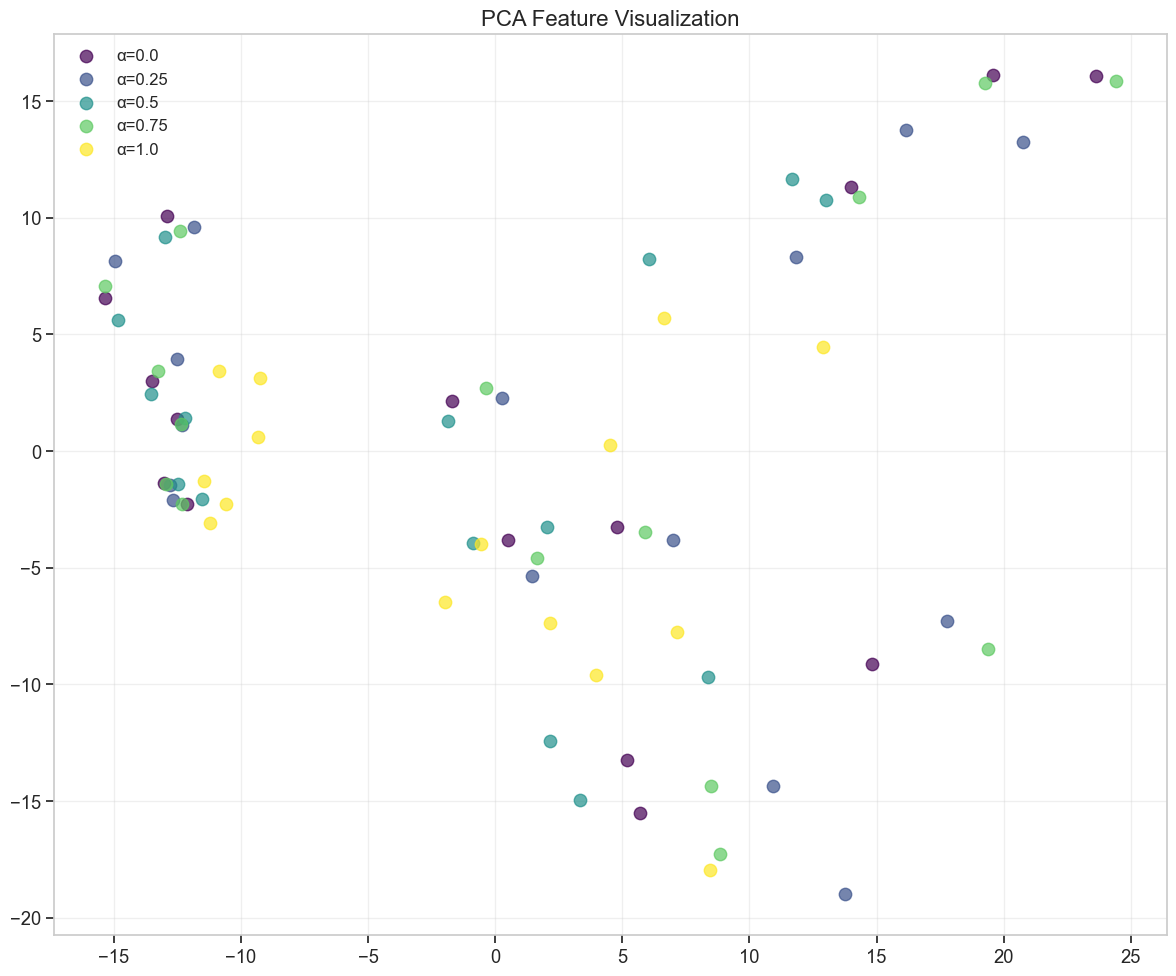

In [29]:
# Visualize features with PCA
print("Creating PCA visualization...")
visualize_features(features_dict, method='pca')

Comparing feature distributions...


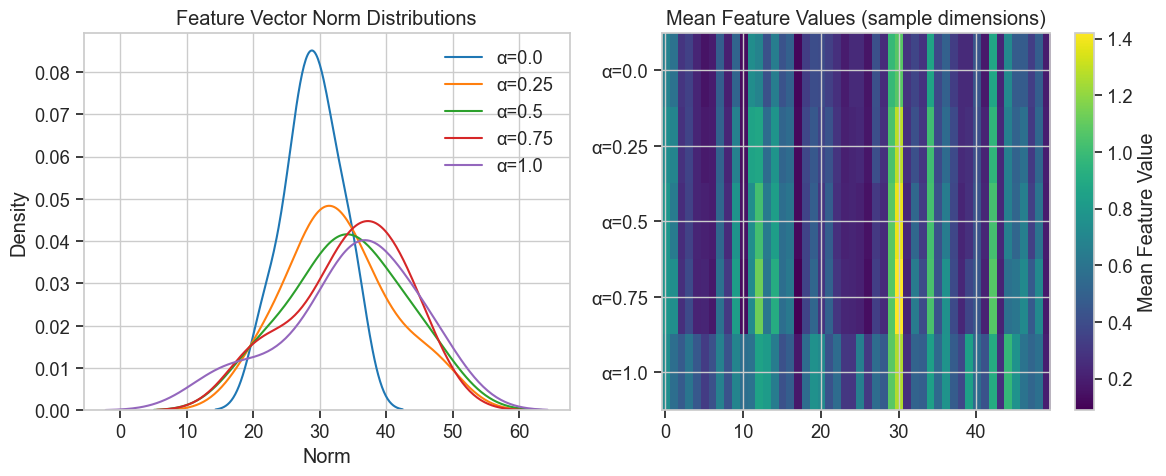

In [30]:
# Compare feature distributions
print("Comparing feature distributions...")
compare_feature_distributions(features_dict)

Analyzing feature similarity...


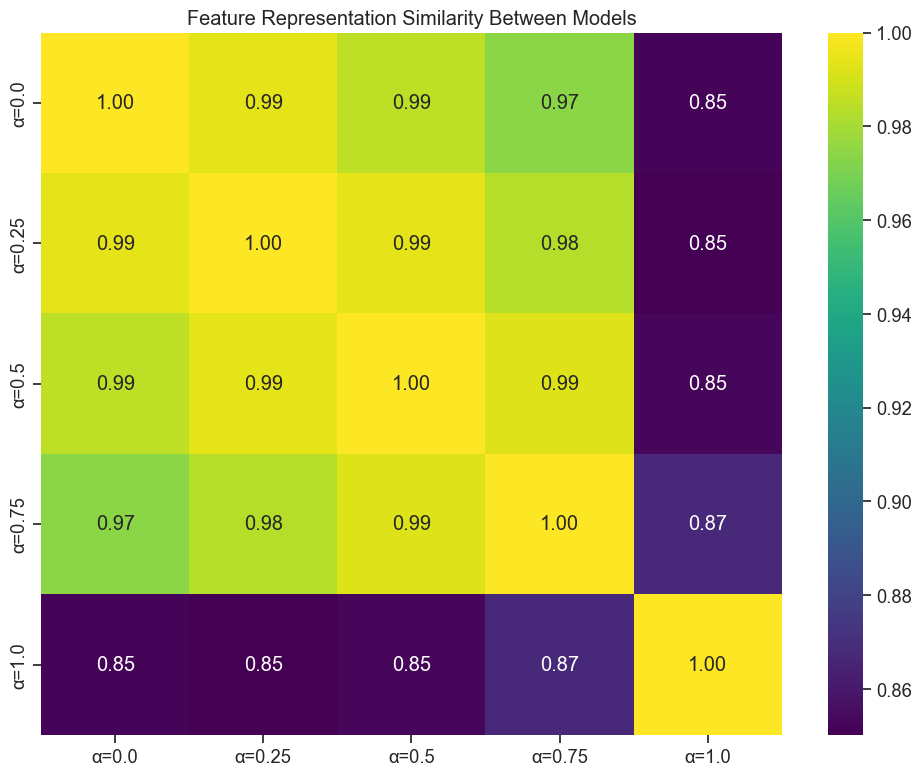

In [31]:
# Analyze feature similarity
print("Analyzing feature similarity...")
analyze_feature_similarity(features_dict)

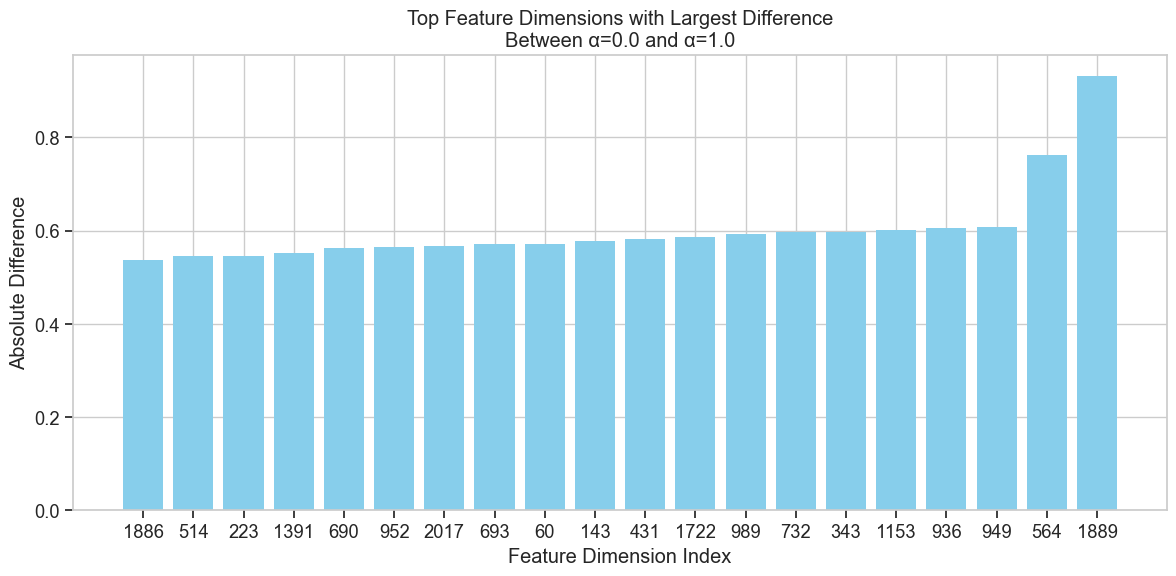

In [32]:
# Analyze which feature dimensions are most affected by alpha
alphas = sorted(features_dict.keys())
if len(alphas) >= 2:
    # Compare models with lowest vs highest alpha
    alpha_min = min(alphas)
    alpha_max = max(alphas)
    
    # Calculate mean features for each model
    mean_features_min = np.mean(features_dict[alpha_min], axis=0)
    mean_features_max = np.mean(features_dict[alpha_max], axis=0)
    
    # Calculate absolute differences
    diff = np.abs(mean_features_max - mean_features_min)
    
    # Find dimensions with biggest differences
    top_dims = np.argsort(diff)[-20:]  # Top 20 dimensions
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    plt.bar(range(len(top_dims)), diff[top_dims], color='skyblue')
    plt.title(f'Top Feature Dimensions with Largest Difference\nBetween α={alpha_min} and α={alpha_max}')
    plt.xlabel('Feature Dimension Index')
    plt.ylabel('Absolute Difference')
    plt.xticks(range(len(top_dims)), top_dims)
    plt.tight_layout()
    plt.show()

<Figure size 1000x800 with 0 Axes>

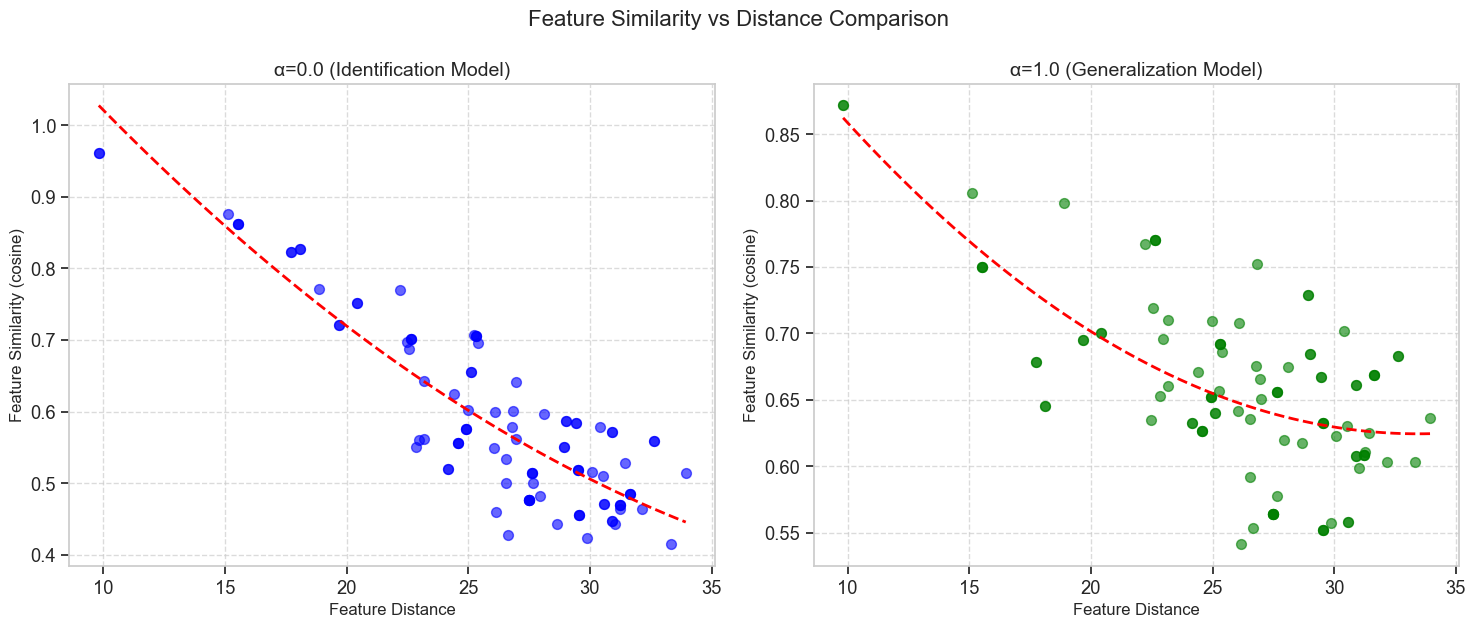

In [40]:
# Create a visualization of feature similarity vs evolutionary distance
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch
import torchvision.transforms as transforms
import random

plt.figure(figsize=(10, 8))

# Get sample images and their species
sample_species = []
for img_path in sample_images:
    # Extract species from path (assuming path format like '/path/to/001.Species_Name/image.jpg')
    path_parts = img_path.split('/')
    for part in path_parts:
        if '.' in part and len(part.split('.')) == 2:
            species_name = part.split('.')[1]
            sample_species.append(species_name)
            break

# Sample pairs of images
pairs = []
n_samples = min(100, len(sample_images) * (len(sample_images) - 1) // 2)

for _ in range(n_samples):
    i, j = random.sample(range(len(sample_images)), 2)
    pairs.append((i, j))

# Collect pairs of evolutionary distance and feature similarity
distances = []
similarities = []

# For each pair, calculate similarity
for i, j in pairs:
    # Get features from both model types
    try:
        # Get features
        feat_a = features_dict[0.0][i]  # From identification model
        feat_b = features_dict[0.0][j]
        
        feat_c = features_dict[1.0][i]  # From generalization model
        feat_d = features_dict[1.0][j]
        
        # Calculate cosine similarity
        sim_id = np.dot(feat_a, feat_b) / (np.linalg.norm(feat_a) * np.linalg.norm(feat_b))
        sim_gen = np.dot(feat_c, feat_d) / (np.linalg.norm(feat_c) * np.linalg.norm(feat_d))
        
        # Calculate Euclidean distance
        eucl_dist = np.linalg.norm(feat_a - feat_b)
        
        # Store the values
        distances.append(eucl_dist)
        similarities.append((sim_id, sim_gen))
    except Exception as e:
        print(f"Error processing pair {i},{j}: {e}")
        continue

# Convert to numpy array for plotting
distances = np.array(distances)
similarities = np.array(similarities)

# Create two subplots
plt.figure(figsize=(15, 6))

# Plot for Identification Model (α=0.0)
plt.subplot(1, 2, 1)
plt.scatter(distances, similarities[:, 0], alpha=0.6, s=50, c='blue')
plt.xlabel('Feature Distance', fontsize=12)
plt.ylabel('Feature Similarity (cosine)', fontsize=12)
plt.title('α=0.0 (Identification Model)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Try to fit a trend line
if len(distances) > 2:
    z = np.polyfit(distances, similarities[:, 0], 2)
    p = np.poly1d(z)
    x_range = np.linspace(min(distances), max(distances), 100)
    plt.plot(x_range, p(x_range), 'r--', linewidth=2)

# Plot for Generalization Model (α=1.0)
plt.subplot(1, 2, 2)
plt.scatter(distances, similarities[:, 1], alpha=0.6, s=50, c='green')
plt.xlabel('Feature Distance', fontsize=12)
plt.ylabel('Feature Similarity (cosine)', fontsize=12)
plt.title('α=1.0 (Generalization Model)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Try to fit a trend line
if len(distances) > 2:
    z = np.polyfit(distances, similarities[:, 1], 2)
    p = np.poly1d(z)
    x_range = np.linspace(min(distances), max(distances), 100)
    plt.plot(x_range, p(x_range), 'r--', linewidth=2)

plt.tight_layout()
plt.suptitle('Feature Similarity vs Distance Comparison', fontsize=16, y=1.05)
plt.show()